# **Assignment 2: Bandits and Exploration/Exploitation**

In this notebook, you will:
- Learn how to create your first bandit algorithm
- Understand the effect of epsilon on exploration and learn about the exploration/exploitation tradeoff
- Be introducing to some of the reinforcement learning software we are going to use for this specialization

This notebook uses RL-Glue to implement most of experiments. It was originally designed by Adam White, Brian Tanner, and Rich Sutton. This library will give you a solid framework to understand how reinforcement learning experiments work and how to run your own.

## **Section 0: Preliminaries**

In [32]:
#---------------------------
# Import necessary libraries
#---------------------------
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from rlglue.rl_glue import RLGlue
import main_agent
import ten_arm_env

You might have noticed that we import ten_arm_env. This is the __10-armed Testbed__ introduced in the textbook. We use this throughout this notebook to test our bandit agents. It has 10 arms, which are the actions the agent can take. Pulling an arm generates a stochastic reward from a Gaussian distribution with unit-variance. For each action, the expected value of that action is randomly sampled from a normal distribution, at the start of each run. If you are unfamiliar with the 10-armed Testbed please review it in the textbook before continuing.

## **Section 1: Greedy Agent**

We want to create an agent that will find the action with the highest expected reward. One way an agent could operate is to always choose the action with  the highest value based on the agent’s current estimates. This is called a greedy agent as it greedily chooses the action that it thinks has the highest value. Let's look at what happens in this case.

First we are going to implement the argmax function, which takes in a list of action values and returns an action with the highest value. Why are we implementing our own instead of using the argmax function that numpy uses? Numpy's argmax function returns the first instance of the highest value. We do not want that to happen as it biases the agent to choose a specific action in the case of ties. Instead we want to break ties between the highest values randomly. So we are going to implement our own argmax function. You may want to look at [np.random.choice](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.choice.html) to randomly select from a list of values.

In [33]:
#---------------------------------------------------------------------------
# Function to find the index of the maximum Q-Value with tie-breaking
#---------------------------------------------------------------------------
def argmax(q_values):
    """
    Finds and returns the index of the highest value in a list of q_values.
    If multiple indices have the highest value (a tie), one is selected randomly.

    Parameters:
    q_values (list): A list of numerical values representing Q-values.
    
    Returns:
    int: The index of the maximum value in q_values. If there are multiple, 
         a random index from the tied values is selected.
    """

    top_value = float("-inf")
    ties = []

    for i in range(len(q_values)):
        # Check if the current value is greater than the highest recorded value
        if q_values[i] > top_value:
            top_value = q_values[i]
            ties = [i]  # reset ties list with the new best index

        # If the current value equals the highest value, add its index to ties
        elif q_values[i] == top_value:
            ties.append(i)

    # Randomly select one of the indices from the ties to break ties fairly
    random_select = np.random.choice(ties)

    return random_select


In [34]:
# --------------------------------------------
# Tests for the argmax function
# --------------------------------------------

# The highest value (1) appears at index 8.
test_array = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
assert argmax(test_array) == 8, "Error: argmax should return index 8 for this test case."

# The highest value (1) appears at indices 0 and 3.
# We set a random seed to ensure consistent results for testing.
np.random.seed(0)  
test_array = [1, 0, 0, 1]
assert argmax(test_array) == 0, "Error: With seed 0, argmax should return index 0."

print("All tests passed successfully!")

All tests passed successfully!


Now we introduce the first part of an RL-Glue agent that you will implement. Here we are going to create a GreedyAgent and implement the agent_step method. This method gets called each time the agent takes a step. The method has to return the action selected by the agent. This method also ensures the agent’s estimates are updated based on the signals it gets from the environment.

Fill in the code below to implement a greedy agent.

In [35]:
# -------------------------------------------------
# GreedyAgent: A greedy reinforcement learning agent
# -------------------------------------------------

class GreedyAgent(main_agent.Agent):
    """
    A greedy agent that selects actions based on the highest estimated value (Q-value).
    It updates its Q-values using an incremental update rule based on received rewards.
    """

    def agent_step(self, t, reward, observation=None):
        """
        Executes one step in the agent's decision process.
        
        Parameters:
        t (int): The current time step.
        reward (float): The reward received from the environment after the last action.
        observation (float, optional): The observed state of the environment.

        Returns:
        int: The action chosen by the agent at the current time step.
        """

        # Step 1: Update the count for the previously taken action
        self.arm_count[self.last_action] += 1

        # Step 2: Compute the step size for updating Q-values (1/n)
        alpha = 1.0 / self.arm_count[self.last_action]

        # Step 3: Apply the incremental update rule for Q-values
        # Q(a) <- Q(a) + alpha * (R - Q(a))
        self.q_values[self.last_action] += alpha * (reward - self.q_values[self.last_action])

        # Step 4: Select the next action using the argmax function (greedy policy)
        current_action = argmax(self.q_values)

        # Step 5: Store the chosen action for the next update
        self.last_action = current_action

        return current_action


Let's visualize the result. Here we run an experiment using RL-Glue to test our agent. For now, we will set up the experiment code; in future lessons, we will walk you through running experiments so that you can create your own.

100%|██████████| 200/200 [00:05<00:00, 33.80it/s]


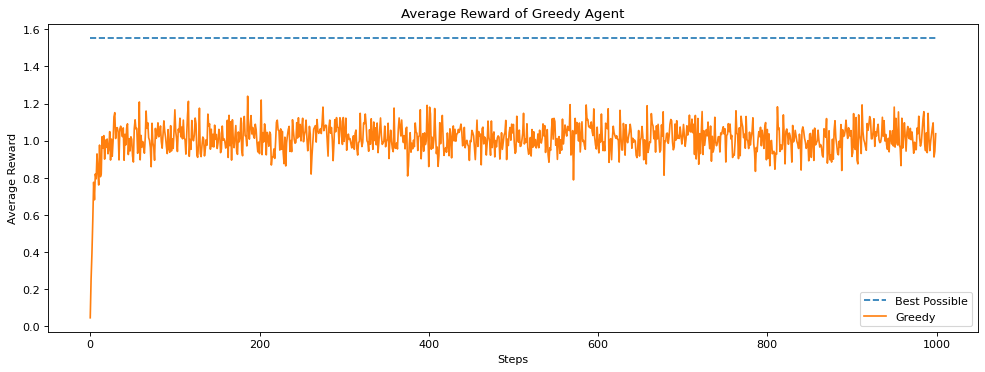

In [36]:
# -----------------------------------------------------------
# Experiment: evaluating the performance of a greedy agent
# -----------------------------------------------------------

# Experiment settings
num_runs = 200                    # The number of independent experiment runs
num_steps = 1000                  # The number of actions taken in each run

# Environment and agent selection
env = ten_arm_env.Environment      # Choosing the 10-armed bandit environment
agent = GreedyAgent                # Selecting the greedy agent for evaluation

# Configuration settings for the agent and environment
agent_info = {"num_actions": 10}   # Passing the number of arms to the agent
env_info = {}                      # No additional parameters needed for the environment

# Initializing reward tracking
rewards = np.zeros((num_runs, num_steps))  # Stores rewards for each run at each step
average_best = 0  # Tracks the average optimal reward across runs

# Running multiple independent experiments
for run in tqdm(range(num_runs)):
    np.random.seed(run)
    
    # Initialize the RLGlue framework with the selected environment and agent
    rl_glue = RLGlue(env, agent)  
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # Track the best possible action's reward for comparison
    average_best += np.max(rl_glue.environment.arms)

    # Run the experiment for the defined number of steps
    for i in range(num_steps):
        # Take a step in the environment and get feedback
        reward, observation, action, terminal = rl_glue.rl_step(i)
        
        # Store the received reward for later analysis
        rewards[run, i] = reward

# Compute the average reward across all runs
greedy_scores = np.mean(rewards, axis=0)

# Visualization of results
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([average_best / num_runs for _ in range(num_steps)], linestyle="--")
plt.plot(greedy_scores)
plt.legend(["Best Possible", "Greedy"])
plt.title("Average Reward of Greedy Agent")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()


**How did our agent do? Is it possible for it to do better?**

The greedy agent performed below optimal because it never explores 
it gets stuck on the first good-looking arm and misses better ones.
Yes, it can do better by adding some exploration


## **Section 2: Epsilon-Greedy Agent**

We learned about another way for an agent to operate, where it does not always take the greedy action. Instead, sometimes it takes an exploratory action. It does this so that it can find out what the best action really is. If we always choose what we think is the current best action is, we may miss out on taking the true best action, because we haven't explored enough times to find that best action.

Implement an epsilon-greedy agent below. You may want to use your greedy code from above and look at [np.random.random](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.random.html), as well as [np.random.randint](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.randint.html), to help you select random actions. 

In [24]:
# ----------------------------------------------------------
# Epsilon-Greedy agent: balancing exploration & exploitation
# ----------------------------------------------------------

class EpsilonGreedyAgent(main_agent.Agent):
    """
    An epsilon-greedy agent that balances exploration and exploitation.
    It updates its Q-values based on received rewards and selects actions 
    either greedily (most rewarding) or randomly (exploration) based on epsilon.
    """

    def agent_step(self, t, reward, observation):
        """
        Executes one step in the agent's decision-making process.
        
        Parameters:
        t (int): The current time step.
        reward (float): The reward received from the environment after the last action.
        observation (float, optional): The observed state of the environment.

        Returns:
        int: The action chosen by the agent at the current time step.
        """

        ### Class Variables for Reference ###
        # self.q_values : A list storing the estimated value of each action (arm).
        # self.arm_count : A list tracking the number of times each action has been selected.
        # self.last_action : The index of the action taken in the previous time step.
        # self.epsilon : Probability of selecting a random action (exploration factor).
        #####################################

        # Step 1: Update Q-values using an incremental update rule
        # Update the count for the previously taken action
        self.arm_count[self.last_action] += 1

        # Compute the step size for Q-value update (1/n)
        alpha = 1.0 / self.arm_count[self.last_action]

        # Apply the incremental Q-value update formula:
        # Q(a) ← Q(a) + α * (R - Q(a)), where α is the step size
        self.q_values[self.last_action] = self.q_values[self.last_action] + alpha * (reward - self.q_values[self.last_action])

        # Step 2: Choose an action using the epsilon-greedy strategy
        if np.random.random() < self.epsilon:
            # Exploratory action: select a random action
            current_action = np.random.randint(self.num_actions)
        else:
            # Exploitative action: select the best action based on current estimates
            current_action = argmax(self.q_values)

        # Step 3: Store the chosen action for the next update
        self.last_action = current_action

        return current_action

Now that we have our epsilon greedy agent created. Let's compare it against the greedy agent with epsilon of 0.1.

100%|██████████| 200/200 [00:05<00:00, 34.67it/s]


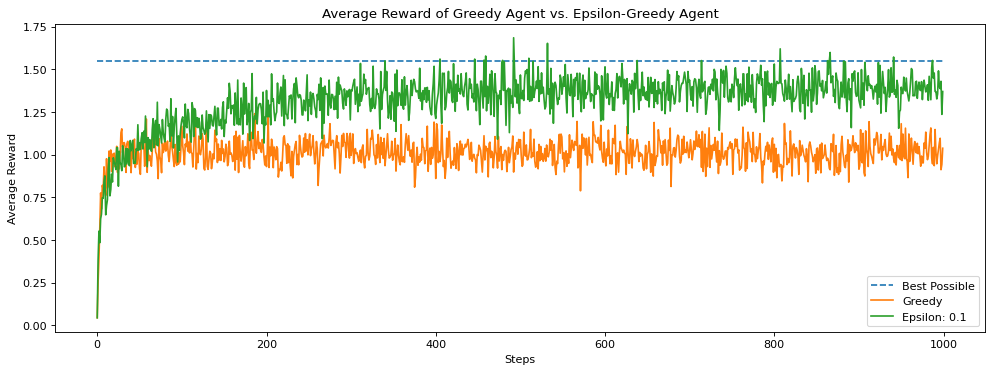

In [50]:
# -----------------------------------------------------------
# Comparing greedy and epsilon-greedy agent performance
# -----------------------------------------------------------

# Experiment settings
num_runs = 200                    # Number of independent experiment runs
num_steps = 1000                  # Number of actions taken in each run
epsilon = 0.1                     # Exploration probability for the epsilon-greedy agent

# Environment and agent selection
agent = EpsilonGreedyAgent
env = ten_arm_env.Environment

# Configuration settings for the agent and environment
agent_info = {"num_actions": 10, "epsilon": epsilon}
env_info = {}

# Initializing reward tracking
all_rewards = np.zeros((num_runs, num_steps))  # Stores rewards for each run at each step

# Running multiple independent experiments
for run in tqdm(range(num_runs)):
    np.random.seed(run)
    
    # Initialize the RLGlue framework with the selected environment and agent
    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # Run the experiment for the defined number of steps
    for i in range(num_steps):
        # Take a step in the environment and get feedback
        reward, observation, action, terminal = rl_glue.rl_step(i)
        
        # Store the received reward for later analysis
        all_rewards[run, i] = reward

# Compute the average reward over all runs for the epsilon-greedy agent
epsilon_greedy_scores = np.mean(all_rewards, axis=0)

# Visualization of results
plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([1.55 for _ in range(num_steps)], linestyle="--")
plt.plot(greedy_scores)
plt.plot(epsilon_greedy_scores)
plt.title("Average Reward of Greedy Agent vs. Epsilon-Greedy Agent")
plt.legend(("Best Possible", "Greedy", "Epsilon: 0.1"))
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()

**Why does the epsilon-greedy strategy often lead to better long-term performance in reinforcement learning?**

Because it balances exploration and exploitation 
most of the time it picks the best known action, but occasionally tries random ones to discover better options.
This prevents the agent from getting stuck on a suboptimal arm, leading to higher average rewards in the long run.

### **Section 2.1 Averaging Multiple Runs**

Did you notice that we averaged over 200 runs? Why did we do that?

To get some insight, let's look at the results of two individual runs by the same agent.

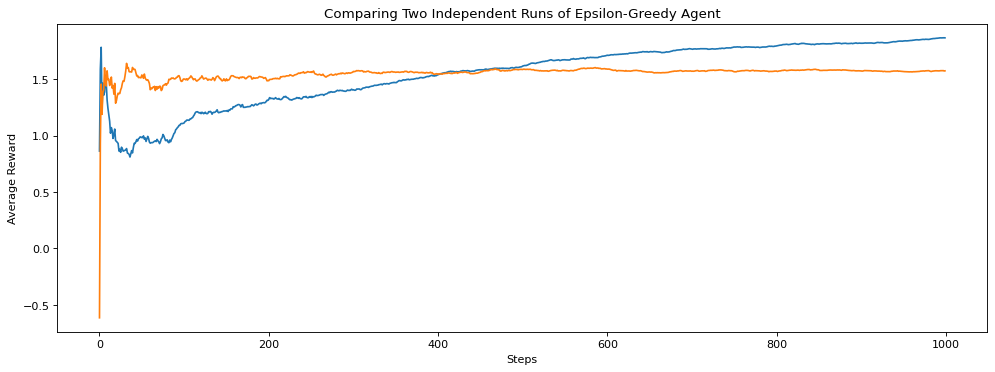

In [51]:
# -------------------------------------------------------------
# Visualizing two independent runs of the epsilon-greedy agent
# -------------------------------------------------------------

agent = EpsilonGreedyAgent
env = ten_arm_env.Environment

agent_info = {"num_actions": 10, "epsilon": 0.1}
env_info = {}

plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

num_steps = 1000

for run in (0, 1):
    np.random.seed(run)
    averages = []

    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    scores = [0]

    for i in range(num_steps):
        # Take a step in the environment and get the reward
        reward, observation, action, terminal = rl_glue.rl_step(i)

        # Update cumulative reward
        scores.append(scores[-1] + reward)

        # Compute the running average reward
        averages.append(scores[-1] / (i + 1))

    plt.plot(averages)

plt.title("Comparing Two Independent Runs of Epsilon-Greedy Agent")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()


**Notice how the two runs were different? But, if this is the exact same algorithm, why does it behave differently in these two runs?**

Because of randomness 
each run uses a different random seed, which changes both the environment's arm values and the agent's exploration decisions.
That's why we average over many runs, to get a reliable measure of true performance rather than a lucky or unlucky result.

The following script shows how setting different random seeds affects the agent's behavior. Specifically, it determines whether the agent takes an exploratory action based on a 10% probability.

In [52]:
# -----------------------------------------------------------
# Demonstrating the effect of random seeds on exploration
# -----------------------------------------------------------

# First run with Random Seed 1
print("Random Seed 1")
np.random.seed(1)  # Set seed for reproducibility
for _ in range(15):  # Loop for 15 time steps
    if np.random.random() < 0.1:  # 10% chance to take an exploratory action
        print("Exploratory Action")  # Print if exploration occurs

print("\n")

# Second run with Random Seed 2
print("Random Seed 2")
np.random.seed(2)  # Set a different seed to observe changes
for _ in range(15):  # Again, loop for 15 time steps
    if np.random.random() < 0.1:  # 10% chance for exploration
        print("Exploratory Action")  # Print if exploration occurs


Random Seed 1
Exploratory Action
Exploratory Action
Exploratory Action


Random Seed 2
Exploratory Action


With the first seed, we take an exploratory action three times out of 15, but with the second, we only take an exploratory action once. This can significantly affect the performance of our agent because the amount of exploration has changed significantly.

To compare algorithms, we therefore report performance averaged across many runs. We do this to ensure that we are not simply reporting a result that is due to stochasticity. Rather, we want statistically significant outcomes. We will not use statistical significance tests. Instead, because we have access to simulators for our experiments, we use the simpler strategy of running for a large number of runs and ensuring that the confidence intervals do not overlap. 

## **Section 3: Comparing values of epsilon**

Can we do better than an epsilon of 0.1? Let's try several different values for epsilon and see how they perform. We try different settings of key performance parameters to understand how the agent might perform under different conditions.

Below we run an experiment to show how different values of epsilon (exploration rate) affect the performance of an epsilon-greedy agent in a multi-armed bandit problem. The results are plotted to show the average rewards over time.

100%|██████████| 200/200 [00:04<00:00, 42.45it/s]


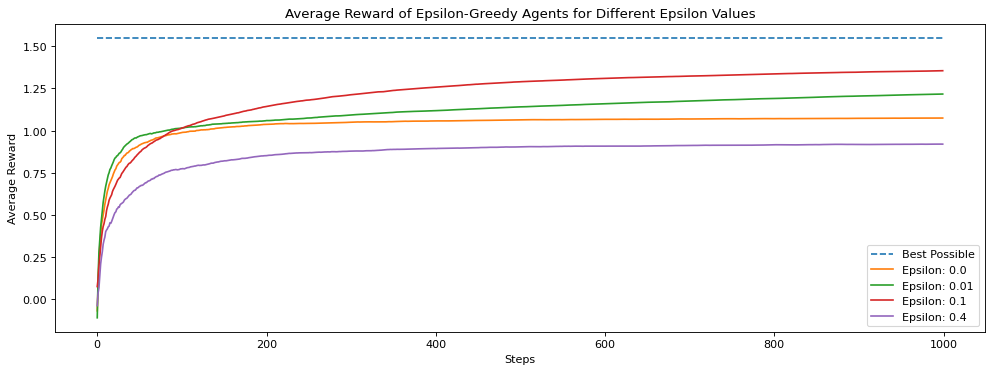

In [53]:
# ------------------------------------------------------------------------
# Comparing different epsilon values in the epsilon-greedy algorithm
# ------------------------------------------------------------------------

epsilons = [0.0, 0.01, 0.1, 0.4]

plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([1.55 for _ in range(num_steps)], linestyle="--")

n_q_values = []
n_averages = []
n_best_actions = []

num_runs = 200

for epsilon in epsilons:
    all_averages = []

    for run in tqdm(range(num_runs)):
        agent = EpsilonGreedyAgent
        agent_info = {"num_actions": 10, "epsilon": epsilon}
        env_info = {"random_seed": run}

        rl_glue = RLGlue(env, agent)
        rl_glue.rl_init(agent_info, env_info)
        rl_glue.rl_start()

        best_arm = np.argmax(rl_glue.environment.arms)

        scores = [0]
        averages = []
        best_action_chosen = []

        for i in range(num_steps):
            # Take a step in the environment and receive feedback
            reward, observation, action, terminal = rl_glue.rl_step(i)

            scores.append(scores[-1] + reward)
            averages.append(scores[-1] / (i + 1))
            best_action_chosen.append(1 if action == best_arm else 0)

            # Save tracking data for epsilon=0.1
            if epsilon == 0.1 and run == 0:
                n_q_values.append(np.copy(rl_glue.agent.q_values))

        all_averages.append(averages)

        if epsilon == 0.1:
            n_best_actions.append(best_action_chosen)

    plt.plot(np.mean(all_averages, axis=0))

plt.legend(["Best Possible"] + [f"Epsilon: {e}" for e in epsilons])
plt.title("Average Reward of Epsilon-Greedy Agents for Different Epsilon Values")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.show()


**Why did 0.1 perform better than 0.01? If exploration helps why did 0.4 perform worse than 0.0 (the greedy agent)?**

epsilon = 0.01 explores too rarely to reliably find the best arm, while epsilon = 0.1 explores just enough to identify and confirm it.
epsilon = 0.4 explores too much 
it wastes 40% of steps on random actions even after already knowing the best arm, which hurts overall reward.


## **Section 4: The effect of step size**

In Section 1 of this assignment, we decayed the step size over time based on action-selection counts. The step-size was 1/N(A), where N(A) is the number of times action A was selected. This is the same as computing a sample average. We could also set the step size to be a constant value, such as 0.1. What would be the effect of doing that? And is it better to use a constant or the sample average method? 

To investigate this question, let’s start by creating a new agent that has a constant step size. This will be nearly identical to the agent created above. You will use the same code to select the epsilon-greedy action. You will change the update to have a constant step size instead of using the 1/N(A) update.

In [54]:
# ---------------------------------------------------------------------
# EpsilonGreedyAgentConstantStepsize: epsilon-greedy with fixed step size
# ---------------------------------------------------------------------

class EpsilonGreedyAgentConstantStepsize(main_agent.Agent):
    """
    An epsilon-greedy agent that uses a constant step size for Q-value updates
    instead of the sample-average (1/N(A)) method.
    """

    def agent_step(self, t, reward, observation=None):
        """
        Executes one step using constant step-size Q-value update.
        
        Parameters:
        t (int): Current time step.
        reward (float): Reward received from the environment.
        observation: Observed state (unused).

        Returns:
        int: The action chosen by the agent.
        """
        # Update Q-values using a constant step size update rule
        # Unlike traditional incremental averaging, this approach does not depend on
        # self.arm_count and instead uses a predefined step size.
        self.q_values[self.last_action] = self.q_values[self.last_action] + self.step_size * (reward - self.q_values[self.last_action])

        # Choose the next action using the epsilon-greedy strategy:
        # - With probability epsilon, select a random action (exploration).
        # - Otherwise, select the action with the highest estimated value (exploitation).
        if np.random.random() < self.epsilon:
            current_action = np.random.randint(self.num_actions)
        else:
            current_action = argmax(self.q_values)

        # Store the chosen action for reference in the next step
        self.last_action = current_action

        return current_action


Let's compare the performance of epsilon-greedy agents using different step size update rules. The step size controls how much each new reward influences the agent’s estimated Q-values.

**Step sizes tested**:
- 0.01, 0.1, 0.5, 1.0: Constant step sizes
- 1/N(A): Incremental averaging (1 divided by the number of times an action has been selected).

Note that performance is measured by tracking the percentage of times the agent selects the optimal action over 1000 steps, averaged over 200 independent runs.

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:05<00:00, 35.40it/s]
C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\522081351.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])


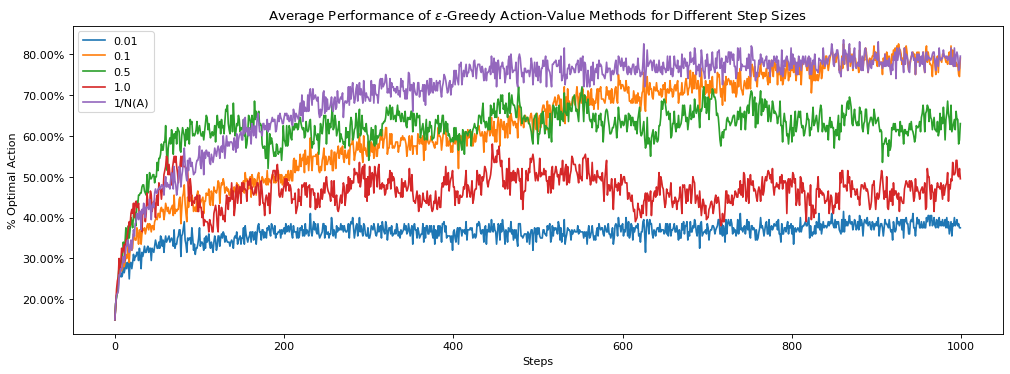

In [55]:
# -----------------------------------------------------------------------------------------
# Experiment: evaluating the performance of epsilon-greedy agents with different step sizes
# -----------------------------------------------------------------------------------------

step_sizes = [0.01, 0.1, 0.5, 1.0, '1/N(A)']
epsilon = 0.1
num_steps = 1000
num_runs = 200

fig, ax = plt.subplots(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

q_values = {step_size: [] for step_size in step_sizes}
true_values = {step_size: None for step_size in step_sizes}
best_actions = {step_size: [] for step_size in step_sizes}

for step_size in step_sizes:
    all_averages = []

    for run in tqdm(range(num_runs)):
        np.random.seed(run)

        agent = EpsilonGreedyAgentConstantStepsize if step_size != '1/N(A)' else EpsilonGreedyAgent
        agent_info = {"num_actions": 10, "epsilon": epsilon, "step_size": step_size, "initial_value": 0.0}
        env_info = {}

        rl_glue = RLGlue(env, agent)
        rl_glue.rl_init(agent_info, env_info)
        rl_glue.rl_start()

        best_arm = np.argmax(rl_glue.environment.arms)

        if run == 0:
            true_values[step_size] = np.copy(rl_glue.environment.arms)

        best_action_chosen = []

        for i in range(num_steps):
            # Run the RL step function
            reward, observation, action, terminal = rl_glue.rl_step(i)

            # Check if the chosen action is the optimal one
            best_action_chosen.append(1 if action == best_arm else 0)

            # Store Q-values for the first run
            if run == 0:
                q_values[step_size].append(np.copy(rl_glue.agent.q_values))

        best_actions[step_size].append(best_action_chosen)

    ax.plot(np.mean(best_actions[step_size], axis=0))

plt.legend(step_sizes)
plt.title(r"Average Performance of $\epsilon$-Greedy Action-Value Methods for Different Step Sizes")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])
plt.show()


Notice first that we are now plotting the amount of time that the best action is taken rather than the average reward. To better  understand the performance of an agent, it can be useful to measure specific behaviors, beyond just how much reward is accumulated. This measure indicates how close the agent’s behaviour is to optimal.

**It seems as though 1/N(A) performed better than the others, in that it reaches a solution where it takes the best action most frequently. Now why might this be? Why did a step size of 0.5 start out better but end up performing worse? Why did a step size of 0.01 perform so poorly?**

1/N(A) converges to the true value because it gives equal weight to all past rewards, making estimates stable over time. 
Step size 0.5 learns fast at first but keeps overreacting to new rewards and never fully settles.
 Step size 0.01 makes such tiny updates that the estimates barely move from zero, so the agent can't tell which arm is best.

### **Estimated values vs. Expected values**
So, the goal now is to observe how quickly and accurately different step sizes allow the agent to approximate the true value of the optimal action.

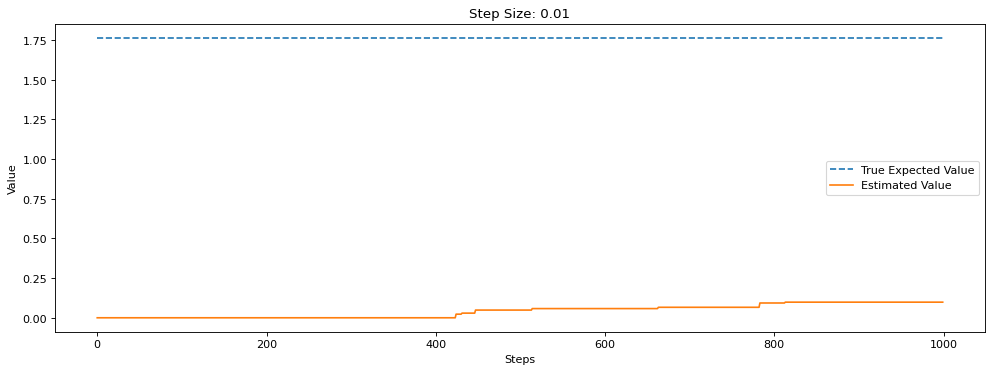

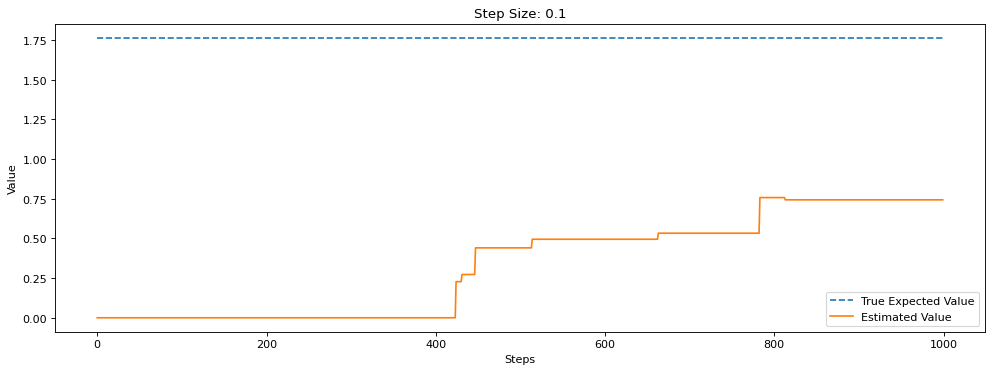

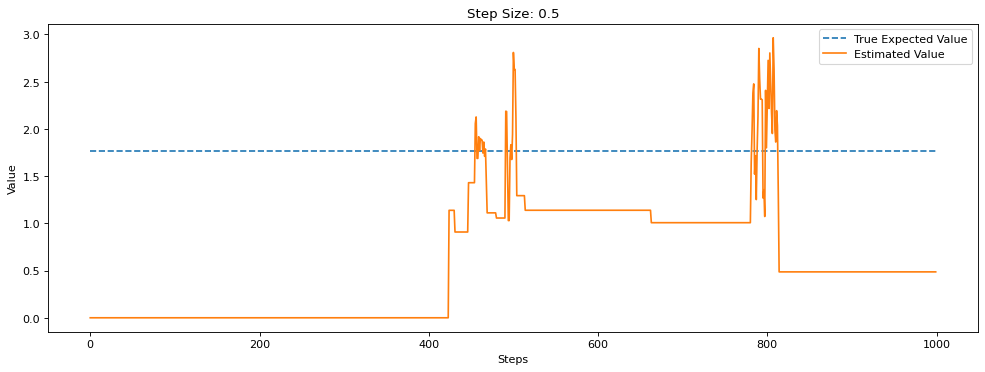

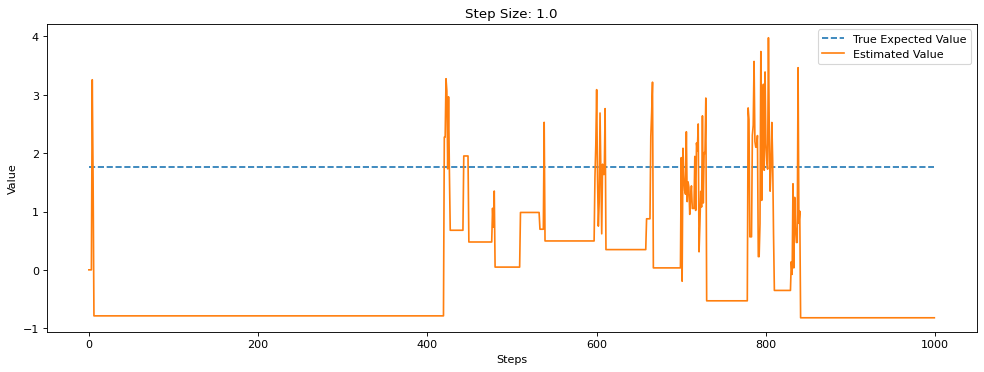

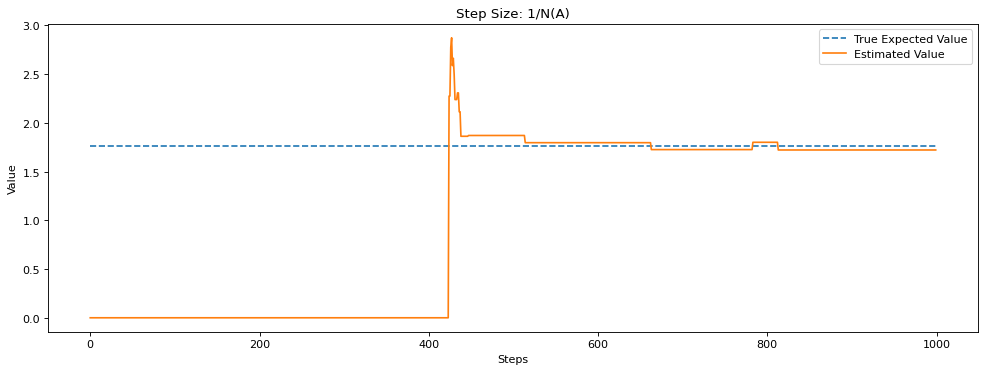

In [56]:
# --------------------------------------------------------------------------------
# Visualizing estimated Q-Values vs. true expected values for different step-sizes
# --------------------------------------------------------------------------------

largest = 0  # Index of the action with the highest true value
num_steps = 1000  # Number of steps in each run

# Iterate over each step size to generate a plot
for step_size in step_sizes:
    plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

    # YOUR CODE HERE
    # Identify the action with the highest true expected value
    
    # Plot the true expected value of the best action as a reference
    plt.plot([true_values[step_size][largest] for _ in range(num_steps)], linestyle="--", label="True Expected Value")

    # Plot the estimated Q-value of the best action over time
    plt.plot(np.array(q_values[step_size])[:, largest], label="Estimated Value")

    # Configure plot settings
    plt.title(f"Step Size: {step_size}")
    plt.xlabel("Steps")
    plt.ylabel("Value")
    plt.legend()
    
    # Show the plot
    plt.show()

These plots help clarify the performance differences between the different step sizes. A step size of 0.01 makes such small updates that the agent’s value estimate of the best action does not get close to the actual value. Step sizes of 0.5 and 1.0 both get close to the true value quickly, but are very susceptible to stochasticity in the rewards. The updates overcorrect too much towards recent rewards, and so oscillate around the true value. This means that on many steps, the action that pulls the best arm may seem worse than it actually is.  A step size of 0.1 updates fairly quickly to the true value, and does not oscillate as widely around the true values as 0.5 and 1.0. This is one of the reasons that 0.1 performs quite well. Finally we see why 1/N(A) performed well. Early on while the step size is still reasonably high it moves quickly to the true expected value, but as it gets pulled more its step size is reduced which makes it less susceptible to the stochasticity of the rewards.

**Does this mean that 1/N(A) is always the best? When might it not be?**

No, 1/N(A) is not always the best 
 it only works well in stationary environments where the reward distributions don't change. In non-stationary problems, the step size shrinks so much over time that the agent can no longer adapt to changes, making a constant step size like 0.1 a better choice.

### **Non-stationary problems**
Let's look at how a sudden change in the reward distributions affects a step size like 1/N(A). This time we will run the environment for 2000 steps, and after 1000 steps we will randomly change the expected value of all of the arms. We compare two agents, both using epsilon-greedy with epsilon = 0.1. One uses a constant step size of 0.1, the other a step size of 1/N(A) that reduces over time. 

100%|██████████| 500/500 [00:27<00:00, 18.35it/s]


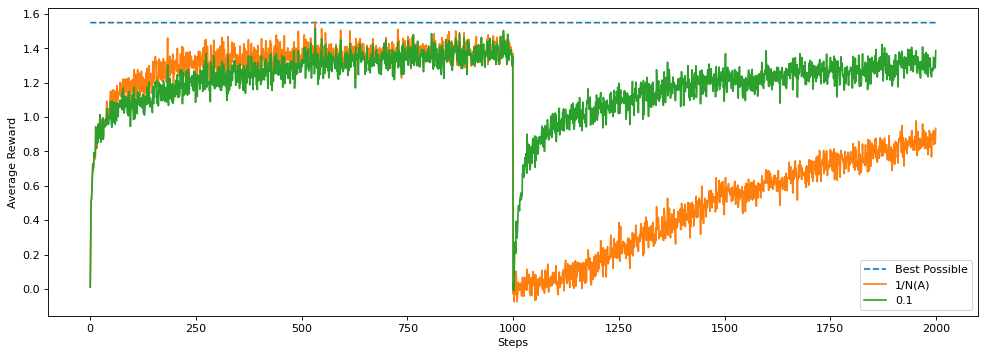

In [57]:
# ------------------------------------------------------------------------------
# Comparing standard and constant step-size epsilon-greedy agents over time
# (with a non-stationary environment shift at step 1000)
# ------------------------------------------------------------------------------

epsilon = 0.1
num_steps = 2000
num_runs = 500
step_size = 0.1

plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([1.55 for _ in range(num_steps)], linestyle="--", label="Best Possible")

for agent in [EpsilonGreedyAgent, EpsilonGreedyAgentConstantStepsize]:
    rewards = np.zeros((num_runs, num_steps))

    for run in tqdm(range(num_runs)):
        agent_info = {"num_actions": 10, "epsilon": epsilon, "step_size": step_size}
        np.random.seed(run)

        # Initialize the RL environment and agent
        rl_glue = RLGlue(ten_arm_env.Environment, agent)
        rl_glue.rl_init(agent_info, {})
        rl_glue.rl_start()

        for i in range(num_steps):
            # At step 1000, randomly shift all arm values (non-stationary environment)
            if i == 1000:
                rl_glue.environment.arms = np.random.randn(10)

            reward, observation, action, terminal = rl_glue.rl_step(i)
            rewards[run, i] = reward

    plt.plot(np.mean(rewards, axis=0), label="1/N(A)" if agent == EpsilonGreedyAgent else "0.1")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.show()


**Now the agent with a step size of 1/N(A) performed better at the start but then performed worse when the environment changed! What happened?**

After 1000 steps, N(A) is very large so the step size becomes tiny (e.g. 1/500), meaning new rewards have almost no influence on the estimates. When the environment changes, the agent can't adapt and keeps exploiting the old best arm, while the constant step-size agent stays responsive and quickly adjusts.

## **Section 5: Upper-Confidence-Bound (UCB) Action Selection**

The **Upper-Confidence-Bound (UCB)** action selection method improves exploration by selecting actions based on their estimated value and an exploration bonus using the following formula:
  $$
  A_t = \arg\max_{a} \left( Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right)
  $$
  where:
  - \(Q_t(a)\) is the estimated value of action \(a\).
  - \(N_t(a)\) is the number of times action \(a\) has been selected.
  - \(t\) is the current time step.
  - \(c\) is a constant that controls exploration.

Complete the function that selects an action based on UCB.

In [58]:
# ------------------------------------------------------------------------------
# Upper Confidence Bound (UCB) agent implementation
# ------------------------------------------------------------------------------

class UCBAgent(main_agent.Agent):
    def agent_step(self, t, reward, observation=None):
        """
        Selects an action based on the Upper Confidence Bound (UCB) strategy.

        Arguments:
        t -- int, current time step.
        reward -- float, the reward received from the previous action.
        observation -- float, observed state (not used).

        Returns:
        current_action -- int, the action selected by the agent.
        """

        if isinstance(self.q_values, list):
            self.q_values = np.array(self.q_values)
        if isinstance(self.arm_count, list):
            self.arm_count = np.array(self.arm_count)

        # Step 1: Update the count and Q-values for the last action
        # Q(a) <- Q(a) + (1/N(a)) * (reward - Q(a))
        self.arm_count[self.last_action] += 1
        alpha = 1.0 / self.arm_count[self.last_action]
        self.q_values[self.last_action] += alpha * (reward - self.q_values[self.last_action])

        # Step 2: Compute UCB estimates for all actions
        # UCB(a) = Q(a) + c * sqrt( log(t+1) / (N(a) + 1e-5) )
        ucb_values = self.q_values + self.ucb_parameter * np.sqrt(
            np.log(t + 1) / (self.arm_count + 1e-5)
        )

        # Step 3: Select the action with the highest UCB estimate (break ties randomly)
        current_action = argmax(ucb_values)

        # Step 4: Store the chosen action for the next step
        self.last_action = current_action

        return current_action


The following experiment compares the performance of Epsilon-Greedy Agent (ε = 0.1) and Upper Confidence Bound (UCB) Agent (c = 2.0). The goal is to analyze how these two strategies perform over time in terms of the obtained average reward.

100%|██████████| 200/200 [00:08<00:00, 23.20it/s]


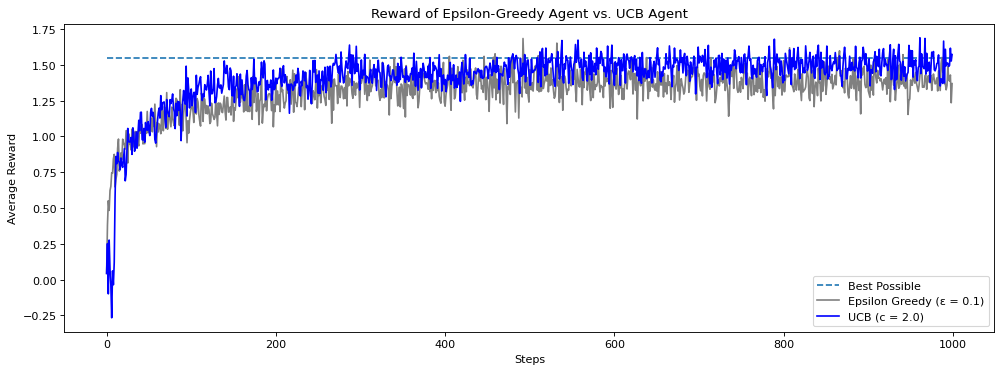

In [59]:
# ------------------------------------------------------------------------------
# Comparing epsilon-greedy and UCB agents
# ------------------------------------------------------------------------------

num_runs = 200
num_steps = 1000
epsilon = 0.1
ucb_parameter = 2.0

agent = UCBAgent
env = ten_arm_env.Environment
agent_info = {"num_actions": 10, "epsilon": epsilon, "ucb_parameter": ucb_parameter}
env_info = {}

all_rewards = np.zeros((num_runs, num_steps))

for run in tqdm(range(num_runs)):
    np.random.seed(run)

    # Initialize the RL environment and agent
    rl_glue = RLGlue(env, agent)
    rl_glue.rl_init(agent_info, env_info)
    rl_glue.rl_start()

    # Simulate agent learning process over num_steps
    for i in range(num_steps):
        reward, observation, action, terminal = rl_glue.rl_step(i)
        all_rewards[run, i] = reward

ucb_scores = np.mean(all_rewards, axis=0)

plt.figure(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')
plt.plot([1.55 for _ in range(num_steps)], linestyle="--", label="Best Possible")
plt.plot(epsilon_greedy_scores, color='grey', label=f"Epsilon Greedy (\u03b5 = {epsilon})")
plt.plot(ucb_scores, color='blue', label=f"UCB (c = {ucb_parameter})")
plt.title("Reward of Epsilon-Greedy Agent vs. UCB Agent")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.show()


**How does the choice of the parameter $c$ affect the agent's performance? How does UCB compare to epsilon-greedy in terms of regret minimization?**

A larger c makes the agent explore more aggressively, while a smaller c makes it more exploitative — too high wastes steps on bad arms, too low misses better ones. UCB is smarter than epsilon-greedy because it focuses exploration on uncertain actions rather than exploring randomly, which leads to lower regret over time.

## **Section 6: Gradient Bandit Algorithm**
The **Gradient Bandit Algorithm** selects actions using a preference function, which is updated based on rewards received.

Implement a bandit agent that uses the **Gradient Bandit Algorithm** using the following update rules:
  $$
  H_t(a) \leftarrow H_t(a) + \alpha (R_t - \bar{R}_t) (1 - P_t(a))
  $$
  where:
  - $H_t(a)$ is the preference for action $a$.
  - $P_t(a)$ is the probability of selecting action $a$ (computed using a softmax function).
  - $\bar{R}_t$ is the running average of past rewards.
  - $\alpha$ is a step-size parameter.
- Compare the performance of the Gradient Bandit Algorithm with epsilon-greedy and UCB.
- Plot the action probabilities over time.

In [60]:
# ------------------------------------------------------------------------------
# Gradient bandit agent implementation
# ------------------------------------------------------------------------------
# This agent follows a gradient-based policy for selecting actions. Instead 
# of maintaining direct value estimates for each action, it updates action 
# preferences based on received rewards.
#
# Features:
# - Uses softmax action selection to determine probabilities.
# - Supports baseline reward subtraction for variance reduction.
# - Updates preferences using the policy gradient update rule.
# ------------------------------------------------------------------------------

class GradientBanditAgent(main_agent.Agent):
    def agent_step(self, t, reward, observation=None):
        """
        Executes a step for the Gradient Bandit Agent.

        Arguments:
        t -- int, current time step.
        reward -- float, reward received after taking the last action.
        observation -- float, observed state (not used).

        Returns:
        current_action -- int, action chosen by the agent at this time step.
        """

        self.indices = np.arange(self.num_actions)

        if isinstance(self.q_values, list):
            self.q_values = np.array(self.q_values)
        if isinstance(self.arm_count, list):
            self.arm_count = np.array(self.arm_count, dtype=float)

        # Step 1: Update the arm count and average reward estimate
        self.arm_count[self.last_action] += 1
        total_steps = t + 1
        # Incremental average reward update: R_bar <- R_bar + (1/t) * (R - R_bar)
        self.average_reward += (1.0 / total_steps) * (reward - self.average_reward)

        # Step 2: Compute the baseline-adjusted reward signal
        # Using current action probabilities (softmax of preferences)
        exp_h = np.exp(self.q_values - np.max(self.q_values))  # numerical stability
        self.action_prob = exp_h / np.sum(exp_h)

        # Compute the policy gradient update for preferences H(a)
        # delta = R - baseline (use average reward as baseline if enabled)
        if self.gradient_baseline:
            baseline = self.average_reward
        else:
            baseline = 0.0

        delta = reward - baseline

        # Update preferences:
        # For the chosen action:    H(A) <- H(A) + alpha * delta * (1 - pi(A))
        # For all other actions:    H(a) <- H(a) - alpha * delta * pi(a)
        one_hot = np.zeros(self.num_actions)
        one_hot[self.last_action] = 1.0
        self.q_values += self.step_size * delta * (one_hot - self.action_prob)

        # Step 3: Compute updated action probabilities using Softmax
        exp_h = np.exp(self.q_values - np.max(self.q_values))
        self.action_prob = exp_h / np.sum(exp_h)

        # Step 4: Select an action based on the updated probabilities
        current_action = np.random.choice(self.indices, p=self.action_prob)

        # Update last action for the next step
        self.last_action = current_action

        return current_action


This experiment evaluates the Gradient Bandit Algorithm on a 10-armed testbed when the $q^*(a)$ are chosen to be near $+4$ rather than near zero. We analyze performance across different step sizes $(α)$ and with/without baseline rewards. The baseline helps reduce variance, leading to more stable learning.

Running step_size=0.1, baseline=True:   0%|          | 0/500 [00:00<?, ?it/s]

Running step_size=0.4, baseline=False: 100%|██████████| 500/500 [00:39<00:00, 12.59it/s]
C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\226320163.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])


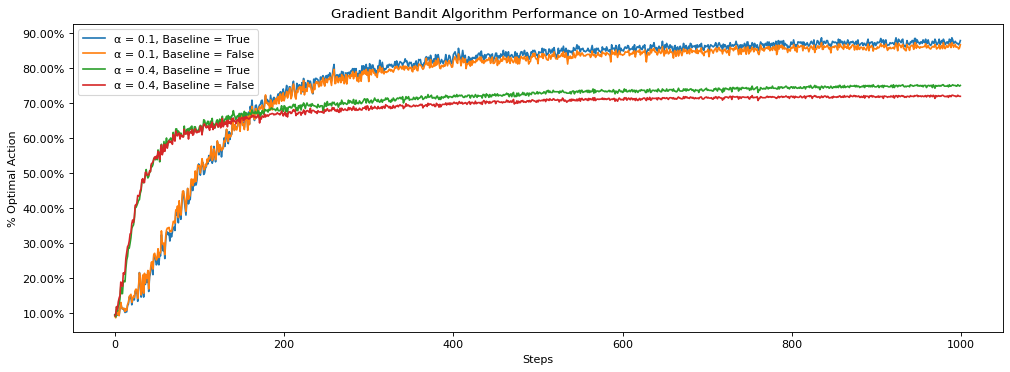

In [61]:
# ------------------------------------------------------------------------------------------------
# Experiment: gradient bandit algorithm with different step-sizes and baselines
# ------------------------------------------------------------------------------------------------

step_sizes = [0.1, 0.4]
gradient_baselines = [True, False]

num_runs = 500
num_steps = 1000
all_rewards = np.zeros((num_runs, num_steps))

q_values = {step_size: [] for step_size in step_sizes}
true_values = {step_size: None for step_size in step_sizes}
best_actions = {step_size: [] for step_size in step_sizes}
legends = []

fig, ax = plt.subplots(figsize=(15, 5), dpi=80, facecolor='w', edgecolor='k')

for step_size in step_sizes:
    for gradient_baseline in gradient_baselines:
        all_averages = []

        for run in tqdm(range(num_runs), desc=f"Running step_size={step_size}, baseline={gradient_baseline}"):
            np.random.seed(run)

            # Initialize agent and environment
            agent = GradientBanditAgent
            agent_info = {
                "num_actions": 10,
                "step_size": step_size,
                "gradient_baseline": gradient_baseline
            }
            env_info = {}

            # Set up RLGlue to handle agent-environment interaction
            rl_glue = RLGlue(ten_arm_env.Environment, agent)
            rl_glue.rl_init(agent_info, env_info)
            rl_glue.rl_start()

            # Identify the best action (arm with the highest true reward)
            best_arm = np.argmax(rl_glue.environment.arms)

            # Store true action values for the first run
            if run == 0:
                true_values[step_size] = np.copy(rl_glue.environment.arms)

            # Track how often the optimal action is selected
            best_action_chosen = []
            for i in range(num_steps):
                # Run RL step function
                reward, observation, action, terminal = rl_glue.rl_step(i)

                # Record whether the best action was taken
                best_action_chosen.append(1 if action == best_arm else 0)

                # Store preference estimates for the first run
                if run == 0:
                    q_values[step_size].append(np.copy(rl_glue.agent.q_values))

            best_actions[step_size].append(best_action_chosen)

        legend_text = f"\u03b1 = {step_size}, Baseline = {gradient_baseline}"
        legends.append(legend_text)
        ax.plot(np.mean(best_actions[step_size], axis=0), label=legend_text)

plt.legend()
plt.title("Gradient Bandit Algorithm Performance on 10-Armed Testbed")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.2%}'.format(x) for x in vals])
plt.show()


**How does the step-size $\alpha$ affect the convergence of the Gradient Bandit Algorithm? Does the algorithm perform better in non-stationary environments?**

A larger alpha learns faster but is noisier and less stable, while a smaller alpha is slower but more reliable 
 the baseline also helps reduce variance significantly.
  Since alpha is constant (not decaying), the algorithm can adapt to environment changes, making it more suitable for non-stationary settings than 1/N(A).

## **Section 7: Conclusion**

Great work! You have:
- Implemented your first agent
- Learned about the effect of epsilon, an exploration parameter, on the performance of an agent
- Learned about the effect of step size on the performance of the agent.
- Learn to solve the multi-armed bandits problem based on several methods.  
- Learned about a good experiment practice of averaging across multiple runs.